In [1]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

# Transfer Learning on AutoEncoders

Test a classifier model trained from scratch vs training first an autoencoder and then transfer the weights to a classfier model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
# ResNet is trained for images in a specific range

from skimage import data


transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data_train = datasets.FashionMNIST(root='data', train=True, download=True, transform=transformer) 
data_dev_test = datasets.FashionMNIST(root='data', train=False, download=True, transform=transformer)   
data_test, data_dev = train_test_split(data_dev_test, test_size=0.5, random_state=42)

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(data_dev, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Data categories: {data_train.classes}")
images.min(), images.max()

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])
Data categories: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


(tensor(-1.), tensor(1.))

In [4]:
class FMNIST_AE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # input size = (1, 28, 28) for FashionMNIST
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = np.floor((28 - 4 + 2*1) / 2) + 1 = 14
            nn.BatchNorm2d(num_features=16), # this is used to normalize the output of the convolutional layer, which can help with training stability and convergence
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = np.floor((14 - 4 + 2*1) / 2) + 1 = 7
            nn.BatchNorm2d(num_features=32), 
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = (7 - 1) * 2 + 4 - 2*1 = 14
            nn.BatchNorm2d(num_features=16), 
            nn.LeakyReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=4, stride=2, padding=1), # output size = (14 - 1) * 2 + 4 - 2*1 = 28
            # do not add BN or activation function here because we want the output to be in the range [-1, 1] to match the normalized input pixel values
            nn.Tanh() # use Tanh activation to ensure the output pixel values are in the range [-1, 1]
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)
        
        return x
    
model = FMNIST_AE().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 14, 14]             272
       BatchNorm2d-2           [-1, 16, 14, 14]              32
         LeakyReLU-3           [-1, 16, 14, 14]               0
            Conv2d-4             [-1, 32, 7, 7]           8,224
       BatchNorm2d-5             [-1, 32, 7, 7]              64
         LeakyReLU-6             [-1, 32, 7, 7]               0
   ConvTranspose2d-7           [-1, 16, 14, 14]           8,208
       BatchNorm2d-8           [-1, 16, 14, 14]              32
         LeakyReLU-9           [-1, 16, 14, 14]               0
  ConvTranspose2d-10            [-1, 1, 28, 28]             257
             Tanh-11            [-1, 1, 28, 28]               0
Total params: 17,089
Trainable params: 17,089
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

In [14]:
# test one forward pass to see the print statements in action
model_ae = FMNIST_AE().to(device)
loss_fn = nn.MSELoss() # for autoencoders, we typically use MSE loss to measure the difference between the input and the reconstructed output
images, labels = next(iter(train_dataloader))
images = images.to(device)
output = model_ae(images)
loss = loss_fn(output, images)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 1, 28, 28])
Loss: 0.9004706740379333


In [6]:
def train_one_epoch_ae(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    device: torch.device,
                    ):
    model.train()
    train_loss = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, X)  # for autoencoders, the target is the input itself

        # Update training loss
        train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss


def train_ae(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device,
          ):

    train_losses_epochs = []
    val_losses_epochs = []

    for epoch in range(epochs):
        train_loss = train_one_epoch_ae(model, train_dataloader, loss_fn, optimizer, device)

        # Calculate average training loss for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        train_losses_epochs.append(avg_train_loss)

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X, y in val_dataloader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = loss_fn(outputs, X)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        val_losses_epochs.append(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    return train_losses_epochs, val_losses_epochs

In [17]:
loss_fn = nn.MSELoss()
epochs = 10

model_ae = FMNIST_AE().to(device)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, val_loss = train_ae(model_ae, train_dataloader, val_dataloader, loss_fn, optimizer, epochs, device)

Epoch [1/10], Train Loss: 0.0196, Val Loss: 0.0064
Epoch [2/10], Train Loss: 0.0062, Val Loss: 0.0040
Epoch [3/10], Train Loss: 0.0042, Val Loss: 0.0029
Epoch [4/10], Train Loss: 0.0033, Val Loss: 0.0020
Epoch [5/10], Train Loss: 0.0030, Val Loss: 0.0018
Epoch [6/10], Train Loss: 0.0026, Val Loss: 0.0023
Epoch [7/10], Train Loss: 0.0024, Val Loss: 0.0017
Epoch [8/10], Train Loss: 0.0023, Val Loss: 0.0020
Epoch [9/10], Train Loss: 0.0022, Val Loss: 0.0018
Epoch [10/10], Train Loss: 0.0020, Val Loss: 0.0015


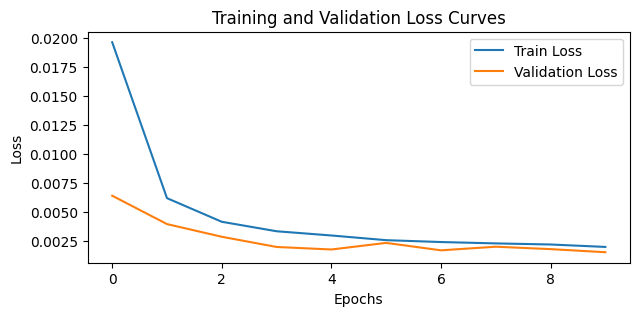

In [18]:
# plot training and validation loss curves
plt.figure(figsize=(7, 3))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

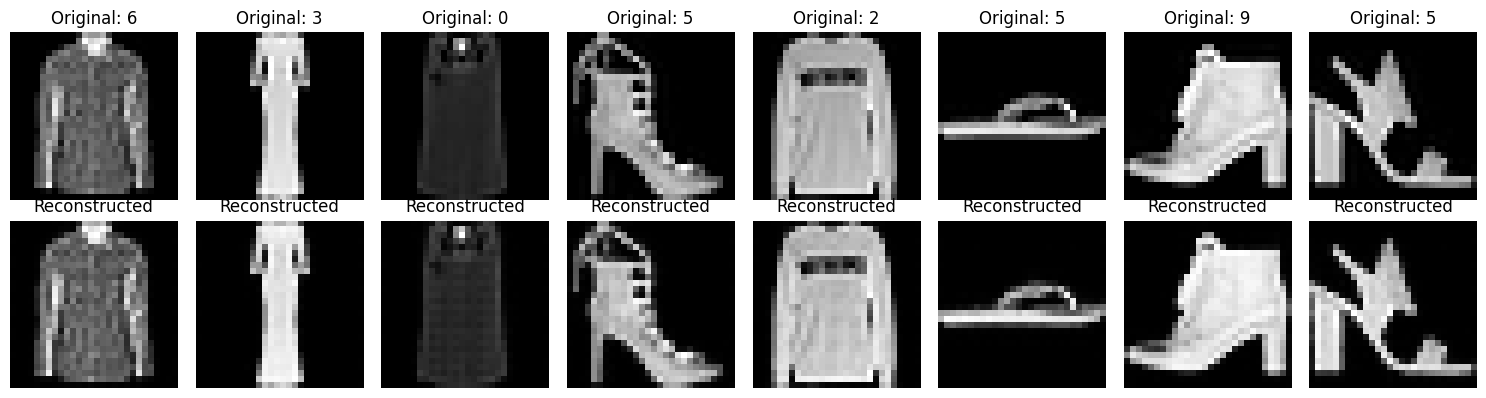

In [19]:
# visualize original and reconstructed images
model_ae.eval()

with torch.no_grad():
    for X, y in val_dataloader:
        X, y = X.to(device), y.to(device)
        outputs = model_ae(X)
        break  # just visualize the first batch
# move tensors to CPU and convert to numpy for visualization
X = X.cpu().numpy()
outputs = outputs.cpu().numpy()
# plot original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i in range(8):
    axes[0, i].imshow(X[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"Original: {y[i].item()}")
    axes[0, i].axis('off')

    axes[1, i].imshow(outputs[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [20]:
def FMNIST_CNN():
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = (28 - 4 + 2*1) / 2 + 1 = 14
        nn.BatchNorm2d(num_features=16),
        nn.LeakyReLU(),

        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = (14 - 4 + 2*1) / 2 + 1 = 7
        nn.BatchNorm2d(num_features=32),
        nn.LeakyReLU(),

        nn.Flatten(), # output size = 32 * 7 * 7 = 1568
        nn.Linear(in_features=32 * 7 * 7, out_features=50),
        nn.LeakyReLU(),
        nn.Linear(in_features=50, out_features=10)
    )
    return model

In [21]:
 # test one forward pass to see the print statements in action
model_cnn = FMNIST_CNN().to(device)
loss_fn = nn.CrossEntropyLoss() 
images, labels = next(iter(train_dataloader))
images, labels = images.to(device), labels.to(device)
output = model_cnn(images)
loss = loss_fn(output, labels)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])
Loss: 2.325277328491211


In [22]:
def train_one_epoch(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   device: torch.device): # Added device
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    
    for batch, (X, y) in enumerate(train_dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device, # Added device
          epochs: int):
    
    # Move the entire model to the device once at the start
    model.to(device)
    
    losses_epochs = [] 
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        # Pass device to the epoch function
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer, device)

        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                # Move test data to device
                X, y = X.to(device), y.to(device)
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [23]:
# trained a new model from scratch (not pre-trained)
loss_fn = nn.CrossEntropyLoss()
epochs = 8
model_cnn = FMNIST_CNN().to(device)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, train_acc, test_acc = train(model_cnn, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/10], Train Loss: 0.4238, Train Accuracy: 0.8473, Test Accuracy: 0.8676
Epoch [2/10], Train Loss: 0.3011, Train Accuracy: 0.8907, Test Accuracy: 0.8808
Epoch [3/10], Train Loss: 0.2641, Train Accuracy: 0.9026, Test Accuracy: 0.8915
Epoch [4/10], Train Loss: 0.2403, Train Accuracy: 0.9118, Test Accuracy: 0.8951
Epoch [5/10], Train Loss: 0.2196, Train Accuracy: 0.9181, Test Accuracy: 0.9043
Epoch [6/10], Train Loss: 0.2042, Train Accuracy: 0.9238, Test Accuracy: 0.9033
Epoch [7/10], Train Loss: 0.1902, Train Accuracy: 0.9285, Test Accuracy: 0.9090
Epoch [8/10], Train Loss: 0.1790, Train Accuracy: 0.9325, Test Accuracy: 0.9120
Epoch [9/10], Train Loss: 0.1668, Train Accuracy: 0.9378, Test Accuracy: 0.9055
Epoch [10/10], Train Loss: 0.1603, Train Accuracy: 0.9396, Test Accuracy: 0.9084


In [37]:
model_cnn_transfer = FMNIST_CNN().to(device)
model_cnn_transfer

Sequential(
  (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=50, bias=True)
  (8): LeakyReLU(negative_slope=0.01)
  (9): Linear(in_features=50, out_features=10, bias=True)
)

In [38]:
model_ae

FMNIST_AE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)

In [46]:
# 1. Access the weights from your trained Autoencoder
ae_state_dict = model_ae.encoder.state_dict() # get just the encoder part

# 2. Get the state_dict of your new CNN
cnn_state_dict = model_cnn_transfer.state_dict()

# 3. Filter out the parts that match (Layers 0 to 5)
# We match by key names. Since both use Sequential, they usually match.
pretrained_dict = {k: v for k, v in ae_state_dict.items() if k in cnn_state_dict}

# 4. Overwrite the weights in the CNN state dict
cnn_state_dict.update(pretrained_dict)

# # 5. Load the updated dictionary back into the CNN
model_cnn_transfer.load_state_dict(cnn_state_dict)

<All keys matched successfully>

In [47]:
loss_fn = nn.CrossEntropyLoss()
epochs = 10
optimizer = torch.optim.Adam(model_cnn_transfer.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, train_acc, test_acc = train(model_cnn_transfer, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/10], Train Loss: 0.3169, Train Accuracy: 0.8828, Test Accuracy: 0.8750
Epoch [2/10], Train Loss: 0.2752, Train Accuracy: 0.8973, Test Accuracy: 0.8929
Epoch [3/10], Train Loss: 0.2525, Train Accuracy: 0.9060, Test Accuracy: 0.8913
Epoch [4/10], Train Loss: 0.2363, Train Accuracy: 0.9128, Test Accuracy: 0.8995
Epoch [5/10], Train Loss: 0.2229, Train Accuracy: 0.9170, Test Accuracy: 0.9015
Epoch [6/10], Train Loss: 0.2092, Train Accuracy: 0.9218, Test Accuracy: 0.8981
Epoch [7/10], Train Loss: 0.1975, Train Accuracy: 0.9257, Test Accuracy: 0.9080
Epoch [8/10], Train Loss: 0.1865, Train Accuracy: 0.9301, Test Accuracy: 0.9003
Epoch [9/10], Train Loss: 0.1781, Train Accuracy: 0.9337, Test Accuracy: 0.9064
Epoch [10/10], Train Loss: 0.1689, Train Accuracy: 0.9374, Test Accuracy: 0.9057
